# Business Understanding

## Project Domain

Project Domain
Retail & E-Commerce / Consumer Electronics

Proyek ini berada di domain penjualan ritel elektronik, khususnya dalam membantu konsumen dan penjual memahami klasifikasi harga laptop berdasarkan spesifikasi teknisnya. Hal ini penting untuk menyusun strategi harga, rekomendasi produk, dan segmentasi pasar.

## Problem Statements



1. Banyak calon pembeli laptop kesulitan menentukan apakah harga suatu laptop tergolong murah, sedang, atau mahal berdasarkan spesifikasi teknisnya.

2. Pihak penjual memerlukan sistem otomatis untuk membantu klasifikasi laptop berdasarkan spesifikasi agar lebih mudah dalam pengelompokan dan penentuan strategi pemasaran.

3. Belum ada model sistematis yang memanfaatkan data historis untuk mengklasifikasikan harga laptop secara otomatis dan objektif.










## Goals



1. Membangun model klasifikasi machine learning yang dapat memprediksi kelas harga laptop (Murah, Sedang, Mahal) berdasarkan spesifikasi seperti merek, prosesor, RAM, penyimpanan, ukuran layar, dan berat.

2. Menyediakan model ringan (TFLite) yang dapat diintegrasikan ke aplikasi berbasis Android atau sistem embedded.

3. Menyimpan preprocessing pipeline (scaler dan encoder) agar proses inferensi dapat diulang dengan data baru.






## Solution Statements



1. Dataset laptop akan dianalisis dan dikonversi dari regresi ke klasifikasi berdasarkan distribusi harga (menggunakan kuantil).

2. Fitur numerik akan dinormalisasi menggunakan MinMaxScaler, dan fitur kategorik seperti merek akan dikodekan dengan OneHotEncoder, semua digabung dalam ColumnTransformer.

3. Model klasifikasi neural network (Keras Sequential) akan dilatih untuk memprediksi harga kategori.

4. Model akan dikonversi ke format .tflite untuk efisiensi dan kemudahan deploy ke perangkat terbatas sumber daya.


5. Pipeline preprocessing disimpan sebagai file .pkl untuk digunakan saat inferensi.





# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"znlindan","key":"c648d1f47af3d2c5995153447c710a79"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d mrsimple07/laptoppriceprediction

Dataset URL: https://www.kaggle.com/datasets/mrsimple07/laptoppriceprediction
License(s): apache-2.0


In [5]:
!mkdir laptoppriceprediction
!unzip laptoppriceprediction.zip -d laptoppriceprediction
!ls laptoppriceprediction

Archive:  laptoppriceprediction.zip
  inflating: laptoppriceprediction/Laptop_price.csv  
Laptop_price.csv


## Import Library yang dibutuhkan

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

## Exploratory Data Analysis

In [25]:
df = pd.read_csv('laptoppriceprediction/Laptop_price.csv')

In [26]:
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


# Data Preparation

In [54]:
bins = df["Price"].quantile([0, 0.33, 0.66, 1.0]).values
labels = [0, 1, 2]
df["Price_Category"] = pd.cut(df["Price"], bins=bins, labels=labels, include_lowest=True)
y = df["Price_Category"].astype(int)
X = df.drop(columns=["Price", "Price_Category"])

In [56]:
categorical = ['Brand']
numerical = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity', 'Screen_Size', 'Weight']
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numerical),
    ('cat', OneHotEncoder(sparse_output=False), categorical) # Use sparse_output=False instead of sparse=False
])
X_prepared = preprocessor.fit_transform(X)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.2, random_state=42)
y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=3)

# Modeling

In [58]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

In [59]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [60]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,843 (46.26 KB)

 Trainable params: 11,843 (46.26 KB)

 Non-trainable params: 0 (0.00 B)

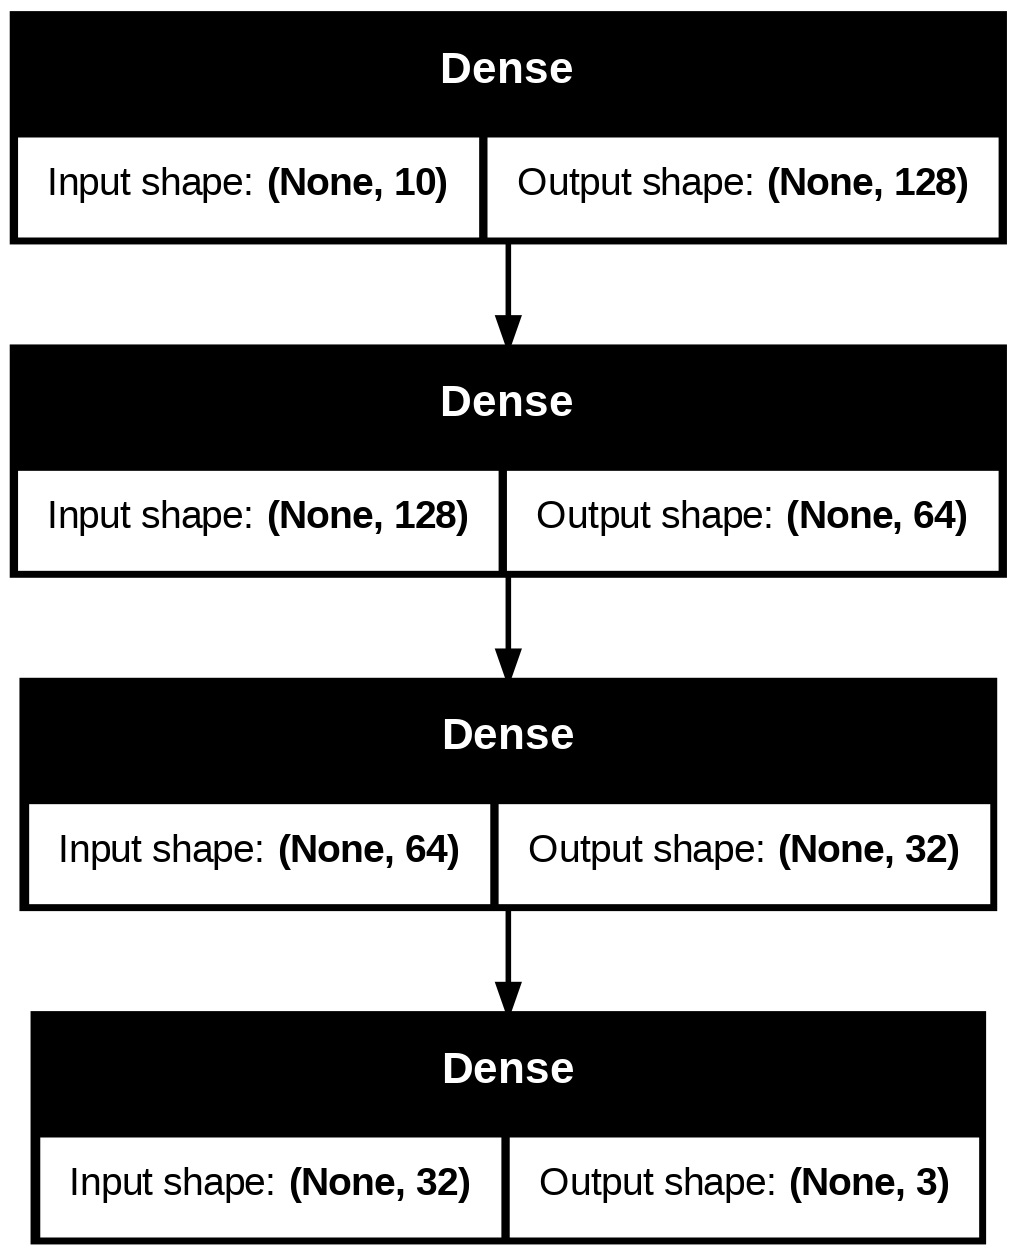

In [61]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [62]:
history = model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5963 - loss: 1.0120 - val_accuracy: 0.9312 - val_loss: 0.7672
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9138 - loss: 0.7508 - val_accuracy: 0.9500 - val_loss: 0.4205
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9438 - loss: 0.4644 - val_accuracy: 0.9875 - val_loss: 0.2318
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9729 - loss: 0.2395 - val_accuracy: 0.9875 - val_loss: 0.1244
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9718 - loss: 0.1432 - val_accuracy: 0.9875 - val_loss: 0.0774
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9701 - loss: 0.1092 - val_accuracy: 0.9875 - val_loss: 0.0563
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9576 - loss: 0.1163 - val_accuracy: 0.9812 - val_loss: 0.0512
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9627 - loss: 0.0934 - val_accuracy: 0.9812 - val_loss

# Evaluation

In [64]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"\nTest Accuracy: {accuracy:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9425 - loss: 0.2617  

Test Accuracy: 0.96


In [65]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [46]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Loss (MSE)')

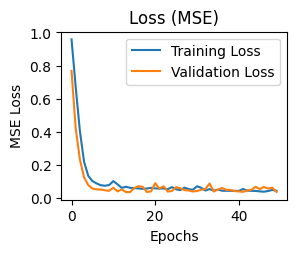

In [66]:
plt.subplot(2, 2, 1)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history["val_loss"], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Loss (MSE)')


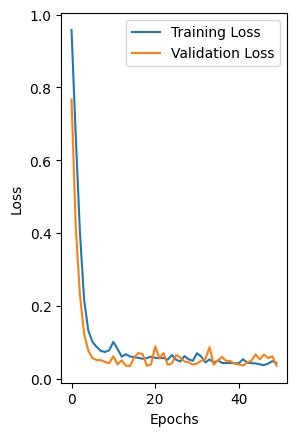

In [67]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

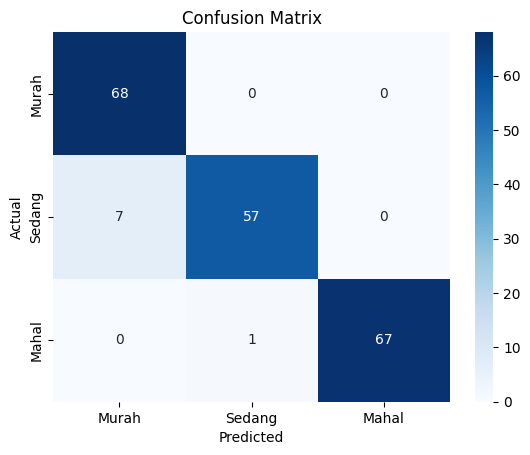

In [68]:
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Murah", "Sedang", "Mahal"], yticklabels=["Murah", "Sedang", "Mahal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [69]:
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=["Murah", "Sedang", "Mahal"]))

Classification Report:
              precision    recall  f1-score   support

       Murah       0.91      1.00      0.95        68
      Sedang       0.98      0.89      0.93        64
       Mahal       1.00      0.99      0.99        68

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



# Deployment

## Model Simulation

In [72]:
sample_input_df = pd.DataFrame([{
    "Brand": "Acer",
    "Processor_Speed": 2.5,
    "RAM_Size": 8,
    "Storage_Capacity": 512,
    "Screen_Size": 15.6,
    "Weight": 1.8
}])

In [73]:
sample_input_scaled = preprocessor.transform(sample_input_df)

In [74]:
prediction = model.predict(sample_input_scaled)
predicted_class = np.argmax(prediction, axis=1)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [75]:
class_mapping = {0: "Murah", 1: "Sedang", 2: "Mahal"}
print(f"Hasil Prediksi: {class_mapping[predicted_class]}")

Hasil Prediksi: Sedang


## Save Model

In [76]:
# Konversi model Keras ke TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model ke file .tflite
with open("laptop_price_classifier.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpudvbvfuw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139197068454480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139197068457552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139197068456592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139197068455056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139197068457168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139197068454288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139197068455248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139197068453712: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [78]:
# Simpan preprocessor (gabungan OneHotEncoder dan MinMaxScaler)
import joblib
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']